In [147]:
import pandas as pd

df = pd.read_csv('data/fraud_scoring_dataset.csv')


In [148]:
df2 =  df.copy()
df2.head()

,transaction_amount,customer_age,account_age_days,num_transactions_30days,failed_login_attempts,international_transaction,fraud_score,first_name,last_name,country,country_risk_group
0,3751.655787,29.478242,955.964040,67.597596,5.719959,0,51.874785,Mia,Martinez,South Africa,medium_risk_country_group
1,9507.635921,51.597859,902.225638,79.871458,8.054323,1,5.116551,Henry,Jackson,Libya,high_risk_country_group
2,7322.619479,72.122642,3307.922964,25.796322,7.601609,0,23.285856,James,Harris,Somalia,high_risk_country_group
3,5990.598257,63.397943,911.594083,62.862536,1.538999,1,49.200173,Lucas,Thompson,Mexico,medium_risk_country_group
4,1568.626218,68.006791,993.344551,57.602852,1.492495,1,31.023528,Mia,Robinson,Iraq,high_risk_country_group


In [149]:
# transaction_amount,country, customer_age and fraud_score

In [150]:
# Correlation for numeric variables
corr_matrix = df2[["transaction_amount", "customer_age", "fraud_score"]].corr(method="pearson")
print("Correlation matrix:\n", corr_matrix, "\n")
print("Correlation with fraud_score:\n", corr_matrix["fraud_score"].sort_values(ascending=False), "\n")

# Relationship between categorical country and fraud_score
country_stats = (
    df2.groupby("country")["fraud_score"]
    .agg(mean_fraud_score="mean", n="count")
    .sort_values("mean_fraud_score", ascending=False)
)

grand_mean = df2["fraud_score"].mean()
ss_between = ((country_stats["mean_fraud_score"] - grand_mean) ** 2 * country_stats["n"]).sum()
ss_total = ((df2["fraud_score"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total if ss_total != 0 else float("nan")

print("Top 10 countries by mean fraud_score:\n", country_stats.head(10), "\n")
print(f"Country -> fraud_score effect size (eta^2): {eta_squared:.4f}")

Correlation matrix:
                     transaction_amount  customer_age  fraud_score
transaction_amount            1.000000      0.029310     0.040464
customer_age                  0.029310      1.000000     0.043484
fraud_score                   0.040464      0.043484     1.000000 

Correlation with fraud_score:
 fraud_score           1.000000
customer_age          0.043484
transaction_amount    0.040464
Name: fraud_score, dtype: float64 

Top 10 countries by mean fraud_score:
                mean_fraud_score   n
country                            
Finland               84.638707  33
Ireland               84.278004  36
Sweden                83.967680  39
Norway                83.910366  31
Canada                83.722539  25
Netherlands           83.698195  38
Germany               83.694377  32
Denmark               82.701435  37
United States         82.177894  28
Switzerland           81.842782  31 

Country -> fraud_score effect size (eta^2): 0.8946


In [151]:
df_features = df2[["transaction_amount", "country", "customer_age", "fraud_score"]].copy()
df_features.head()

,transaction_amount,country,customer_age,fraud_score
0,3751.655787,South Africa,29.478242,51.874785
1,9507.635921,Libya,51.597859,5.116551
2,7322.619479,Somalia,72.122642,23.285856
3,5990.598257,Mexico,63.397943,49.200173
4,1568.626218,Iraq,68.006791,31.023528


In [152]:
# df_features2 = df2[["transaction_amount", "country", "customer_age", "country_risk_group"]].copy()
# df_features2.head()

In [153]:
df_features.country.value_counts()

country
Somalia          47
Mexico           40
Brazil           40
Philippines      40
Libya            39
Sweden           39
Afghanistan      39
Netherlands      38
Denmark          37
Malaysia         37
Ireland          36
Vietnam          35
Yemen            35
Sudan            35
India            34
Finland          33
Germany          32
Thailand         32
Iraq             32
Norway           31
Venezuela        31
Switzerland      31
United States    28
Indonesia        27
Turkey           27
Myanmar          26
Syria            26
North Korea      25
Canada           25
South Africa     23
Name: count, dtype: int64

In [154]:
# how many distinct countries in df_features.country
df_features.country.nunique()

30

### Normalizing Data with Z-Score Normalization

In [156]:
# Z-Score Normalization: z = (x - μ) / σ
numeric_cols = ['transaction_amount', 'customer_age']

df_zscore = df_features.copy()

for col in numeric_cols:
    mean = df_zscore[col].mean()
    std = df_zscore[col].std()
    df_zscore[col] = (df_zscore[col] - mean) / std

print("Z-Score Normalized DataFrame:")
print(df_zscore.head(10))
print("\nVerification - Mean (should be ~0) and Std (should be ~1):")
print(df_zscore[numeric_cols].agg(['mean', 'std']))

Z-Score Normalized DataFrame:
   transaction_amount       country  customer_age  fraud_score
0           -0.396103  South Africa     -1.101627    51.874785
1            1.576169         Libya      0.119387     5.116551
2            0.827479       Somalia      1.252365    23.285856
3            0.371065        Mexico      0.770758    49.200173
4           -1.144112          Iraq      1.025168    31.023528
5           -1.144195          Iraq      0.519409    18.176360
6           -1.479348        Turkey      0.634037    50.413284
7            1.286791       Myanmar      1.171082    32.280979
8            0.379474          Iraq     -0.880760    25.810764
9            0.745595      Malaysia     -0.060209    46.398542

Verification - Mean (should be ~0) and Std (should be ~1):
      transaction_amount  customer_age
mean       -4.440892e-17  4.263256e-17
std         1.000000e+00  1.000000e+00


In [159]:
# One-Hot Encoding for the 'country' column
df_encoded = pd.get_dummies(df_zscore, columns=['country'], drop_first=True)

print("One-Hot Encoded DataFrame:")
print(df_encoded.head())
print(f"\nShape: {df_encoded.shape}")
print(f"\nColumns: {df_encoded.columns.tolist()}")

One-Hot Encoded DataFrame:
   transaction_amount  customer_age  fraud_score  country_Brazil  \
0           -0.396103     -1.101627    51.874785           False   
1            1.576169      0.119387     5.116551           False   
2            0.827479      1.252365    23.285856           False   
3            0.371065      0.770758    49.200173           False   
4           -1.144112      1.025168    31.023528           False   

   country_Canada  country_Denmark  country_Finland  country_Germany  \
0           False            False            False            False   
1           False            False            False            False   
2           False            False            False            False   
3           False            False            False            False   
4           False            False            False            False   

   country_India  country_Indonesia  ...  country_Sudan  country_Sweden  \
0          False              False  ...          False 

In [161]:
# One-Hot Encoding for the 'country' column and add to df_features
country_dummies = pd.get_dummies(df_features['country'], prefix='country', drop_first=True)
df_features = pd.concat([df_features.drop(columns=['country']), country_dummies], axis=1)

print("df_features with One-Hot Encoded country column:")
print(df_features.head())
print(f"\nShape: {df_features.shape}")
print(f"\nColumns: {df_features.columns.tolist()}")

df_features with One-Hot Encoded country column:
   transaction_amount  customer_age  fraud_score  country_Brazil  \
0         3751.655787     29.478242    51.874785           False   
1         9507.635921     51.597859     5.116551           False   
2         7322.619479     72.122642    23.285856           False   
3         5990.598257     63.397943    49.200173           False   
4         1568.626218     68.006791    31.023528           False   

   country_Canada  country_Denmark  country_Finland  country_Germany  \
0           False            False            False            False   
1           False            False            False            False   
2           False            False            False            False   
3           False            False            False            False   
4           False            False            False            False   

   country_India  country_Indonesia  ...  country_Sudan  country_Sweden  \
0          False              Fals

In [162]:
df_features.columns


Index(['transaction_amount', 'customer_age', 'fraud_score', 'country_Brazil',
       'country_Canada', 'country_Denmark', 'country_Finland',
       'country_Germany', 'country_India', 'country_Indonesia', 'country_Iraq',
       'country_Ireland', 'country_Libya', 'country_Malaysia',
       'country_Mexico', 'country_Myanmar', 'country_Netherlands',
       'country_North Korea', 'country_Norway', 'country_Philippines',
       'country_Somalia', 'country_South Africa', 'country_Sudan',
       'country_Sweden', 'country_Switzerland', 'country_Syria',
       'country_Thailand', 'country_Turkey', 'country_United States',
       'country_Venezuela', 'country_Vietnam', 'country_Yemen'],
      dtype='object')

In [163]:
df_features.head()

,transaction_amount,customer_age,fraud_score,country_Brazil,country_Canada,country_Denmark,country_Finland,country_Germany,country_India,country_Indonesia,...,country_Sudan,country_Sweden,country_Switzerland,country_Syria,country_Thailand,country_Turkey,country_United States,country_Venezuela,country_Vietnam,country_Yemen
0,3751.655787,29.478242,51.874785,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,9507.635921,51.597859,5.116551,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7322.619479,72.122642,23.285856,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,5990.598257,63.397943,49.200173,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1568.626218,68.006791,31.023528,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [164]:
# Verify which country was dropped
all_countries = set(df_features['country'].unique()) if 'country' in df_features.columns else set(df2['country'].unique())
encoded_countries = {col.replace('country_', '') for col in df_encoded.columns if col.startswith('country_')}

dropped_countries = all_countries - encoded_countries
print(f"Total unique countries: {len(all_countries)}")
print(f"Encoded country columns: {len(encoded_countries)}")
print(f"Dropped country (drop_first=True): {dropped_countries}")
print(f"\nTotal columns in df_encoded: {df_encoded.shape[1]}")
print(f"Breakdown: 29 country dummies + transaction_amount + customer_age + fraud_score = 32")

Total unique countries: 30
Encoded country columns: 29
Dropped country (drop_first=True): {'Afghanistan'}

Total columns in df_encoded: 32
Breakdown: 29 country dummies + transaction_amount + customer_age + fraud_score = 32


In [ ]:
# One-Hot Encoding for the 'country' column - keep ALL countries including Afghanistan
df_encoded = pd.get_dummies(df_zscore, columns=['country'], drop_first=False)

print("One-Hot Encoded DataFrame (no dropped country):")
print(df_encoded.head())
print(f"\nShape: {df_encoded.shape}")
print(f"\nColumns: {df_encoded.columns.tolist()}")

# Verify Afghanistan column exists
afghan_cols = [col for col in df_encoded.columns if 'Afghanistan' in col]
print(f"\nAfghanistan column: {afghan_cols}")

In [166]:
df_encoded.head()

,transaction_amount,customer_age,fraud_score,country_Brazil,country_Canada,country_Denmark,country_Finland,country_Germany,country_India,country_Indonesia,...,country_Sudan,country_Sweden,country_Switzerland,country_Syria,country_Thailand,country_Turkey,country_United States,country_Venezuela,country_Vietnam,country_Yemen
0,-0.396103,-1.101627,51.874785,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.576169,0.119387,5.116551,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.827479,1.252365,23.285856,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.371065,0.770758,49.200173,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.144112,1.025168,31.023528,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [167]:
# df_features.head()

In [169]:
import numpy as np

# Prepare features (X) and target (y) from df_encoded
feature_cols = [col for col in df_encoded.columns if col != 'fraud_score']
X_lr = df_encoded[feature_cols].astype(float).values
y_lr = df_encoded['fraud_score'].values

# Split into train/test (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X_lr))
train_size = int(0.8 * len(X_lr))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train_lr, X_test_lr = X_lr[train_idx], X_lr[test_idx]
y_train_lr, y_test_lr = y_lr[train_idx], y_lr[test_idx]

# Add bias column (column of 1s) for intercept b
X_train_b = np.hstack([X_train_lr, np.ones((X_train_lr.shape[0], 1))])
X_test_b  = np.hstack([X_test_lr,  np.ones((X_test_lr.shape[0],  1))])

# Solve using Normal Equation: w = (X^T X)^-1 X^T y
weights = np.linalg.lstsq(X_train_b, y_train_lr, rcond=None)[0]

# Extract weights and bias
w = weights[:-1]   # feature weights
b = weights[-1]    # intercept / bias

# Predict: f(x) = w1*x1 + w2*x2 + ... + wn*xn + b
y_pred_lr = X_test_b @ weights

# Evaluate with MSE and R²
mse  = np.mean((y_test_lr - y_pred_lr) ** 2)
ss_res = np.sum((y_test_lr - y_pred_lr) ** 2)
ss_tot = np.sum((y_test_lr - y_test_lr.mean()) ** 2)
r2   = 1 - ss_res / ss_tot

print("Linear Regression: f(x) = w1*x1 + w2*x2 + ... + wn*xn + b")
print(f"\nBias (b): {b:.4f}")
print(f"\nTop feature weights:")
weight_series = dict(zip(feature_cols, w))
for name, val in sorted(weight_series.items(), key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {name:30s}: {val:.4f}")

print(f"\nMSE  : {mse:.4f}")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"R²   : {r2:.4f}")

print("\nSample predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {y_pred_lr[i]:.2f}  |  Actual: {y_test_lr[i]:.2f}")

Linear Regression: f(x) = w1*x1 + w2*x2 + ... + wn*xn + b

Bias (b): 18.8672

Top feature weights:
  country_Ireland               : 66.1727
  country_Finland               : 65.2739
  country_Canada                : 65.1872
  country_Norway                : 64.9863
  country_Switzerland           : 64.2835
  country_Netherlands           : 64.2281
  country_Denmark               : 64.0610
  country_Sweden                : 64.0385
  country_Germany               : 63.8917
  country_United States         : 62.7665

MSE  : 96.7539
RMSE : 9.8364
R²   : 0.8789

Sample predictions vs actual:
  Predicted: 48.90  |  Actual: 47.19
  Predicted: 48.78  |  Actual: 40.57
  Predicted: 49.71  |  Actual: 54.41
  Predicted: 84.58  |  Actual: 88.13
  Predicted: 14.31  |  Actual: 5.51


In [170]:
# Comparison table with percentage performance
comparison_df = pd.DataFrame({
    'Actual': y_test_lr,
    'Predicted': y_pred_lr,
    'Residual': y_test_lr - y_pred_lr,
    'Abs_Error': np.abs(y_test_lr - y_pred_lr),
    'Pct_Error (%)': np.abs(y_test_lr - y_pred_lr) / np.where(y_test_lr != 0, np.abs(y_test_lr), np.nan) * 100,
    'Accuracy (%)': 100 - (np.abs(y_test_lr - y_pred_lr) / np.where(y_test_lr != 0, np.abs(y_test_lr), np.nan) * 100)
})

comparison_df.index = range(len(comparison_df))
comparison_df = comparison_df.round(2)

print("Actual vs Predicted Fraud Score with Percentage Performance (Linear Regression)")
print("=" * 90)
print(f"{'#':<5} {'Actual':>10} {'Predicted':>12} {'Residual':>12} {'Abs Error':>12} {'Pct Err%':>10} {'Accuracy%':>11}")
print("-" * 90)
for i, row in comparison_df.iterrows():
    print(f"{i:<5} {row['Actual']:>10.2f} {row['Predicted']:>12.2f} {row['Residual']:>12.2f} {row['Abs_Error']:>12.2f} {row['Pct_Error (%)']:>10.2f} {row['Accuracy (%)']:>11.2f}")

print("\nSummary Statistics:")
print(f"  Mean Absolute Error     : {comparison_df['Abs_Error'].mean():.4f}")
print(f"  Mean Percentage Error   : {comparison_df['Pct_Error (%)'].mean():.4f}%")
print(f"  Mean Accuracy           : {comparison_df['Accuracy (%)'].mean():.4f}%")
print(f"  Max Absolute Error      : {comparison_df['Abs_Error'].max():.4f}")
print(f"  Min Absolute Error      : {comparison_df['Abs_Error'].min():.4f}")
print(f"  Std of Residuals        : {comparison_df['Residual'].std():.4f}")

Actual vs Predicted Fraud Score with Percentage Performance (Linear Regression)
#         Actual    Predicted     Residual    Abs Error   Pct Err%   Accuracy%
------------------------------------------------------------------------------------------
0          47.19        48.90        -1.71         1.71       3.62       96.38
1          40.57        48.78        -8.21         8.21      20.23       79.77
2          54.41        49.71         4.70         4.70       8.64       91.36
3          88.13        84.58         3.54         3.54       4.02       95.98
4           5.51        14.31        -8.80         8.80     159.75      -59.75
5          83.24        83.41        -0.17         0.17       0.21       99.79
6          20.93        14.57         6.36         6.36      30.40       69.60
7          62.83        50.91        11.93        11.93      18.98       81.02
8           9.07        14.69        -5.62         5.62      61.95       38.05
9          10.43        15.03        -4

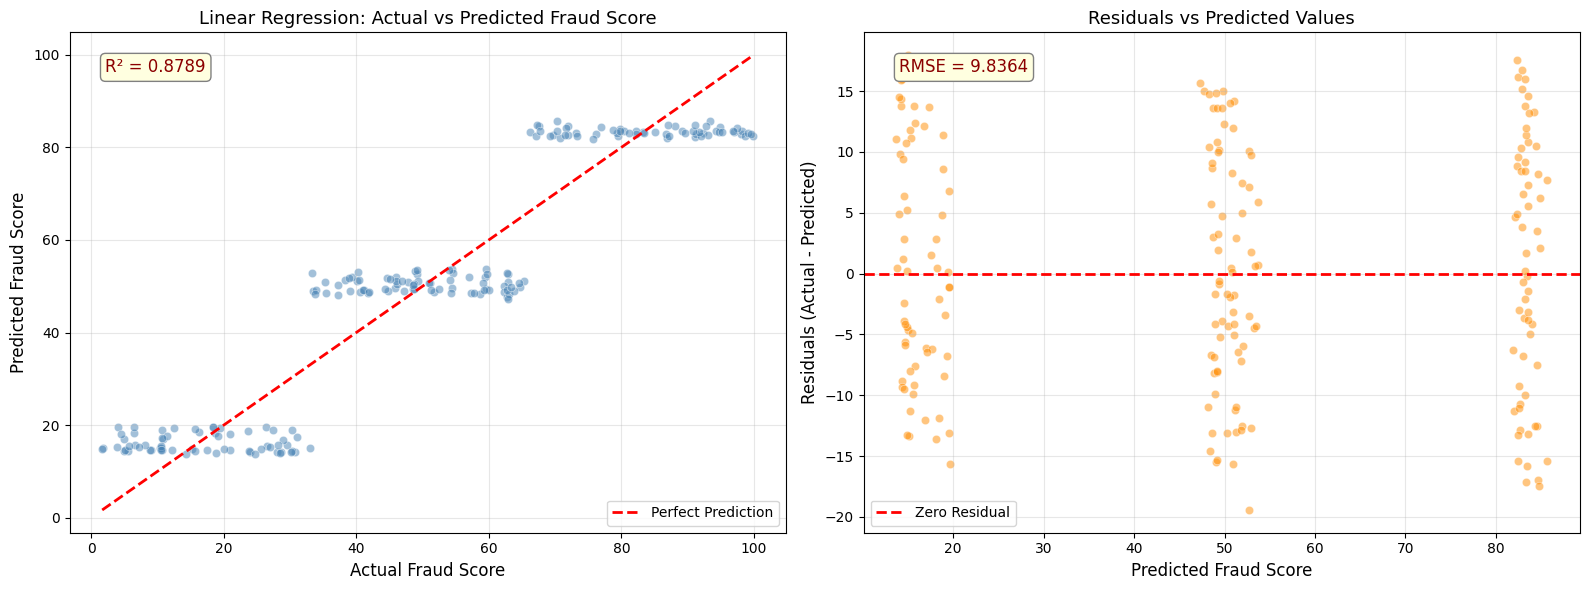

In [172]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted (Linear Regression - continuous fraud_score)
axes[0].scatter(y_test_lr, y_pred_lr, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test_lr.min(), y_pred_lr.min())
max_val = max(y_test_lr.max(), y_pred_lr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Fraud Score', fontsize=12)
axes[0].set_ylabel('Predicted Fraud Score', fontsize=12)
axes[0].set_title('Linear Regression: Actual vs Predicted Fraud Score', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add R² annotation
ss_res = np.sum((y_test_lr - y_pred_lr) ** 2)
ss_tot = np.sum((y_test_lr - y_test_lr.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
axes[0].annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# Plot 2: Residuals vs Predicted
residuals = y_test_lr - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.5, color='darkorange', edgecolors='white', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residual')
axes[1].set_xlabel('Predicted Fraud Score', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residuals vs Predicted Values', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

rmse = np.sqrt(np.mean(residuals ** 2))
axes[1].annotate(f'RMSE = {rmse:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

         MODEL EVALUATION METRICS
  MSE  (Mean Squared Error)  : 96.7539
  RMSE (Root MSE)            : 9.8364
  MAE  (Mean Absolute Error) : 8.5112
  R²   (R-Squared)           : 0.8789


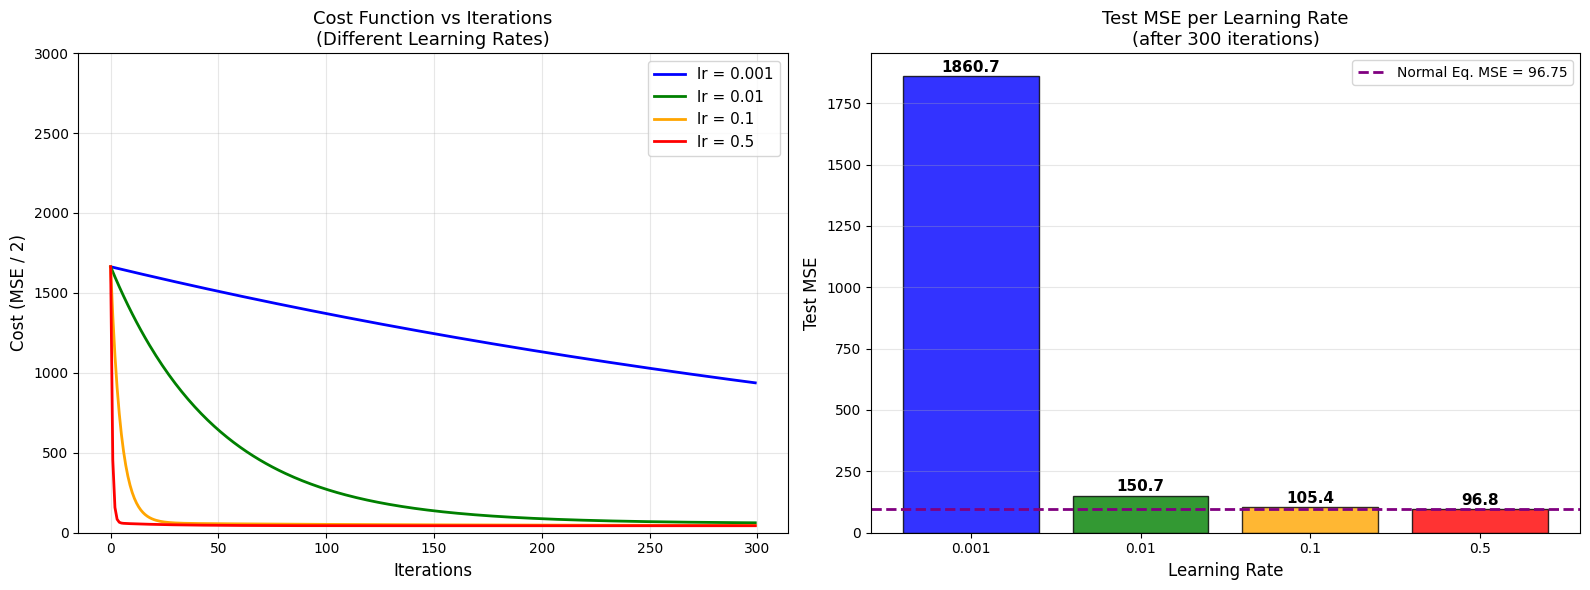


Normal Equation MSE (optimal): 96.7539

Gradient Descent Test MSE per Learning Rate:
  lr = 0.001  -> MSE = 1860.6770
  lr = 0.01   -> MSE = 150.7469
  lr = 0.1    -> MSE = 105.4469
  lr = 0.5    -> MSE = 96.7937


In [173]:
# MSE, Cost Function and Learning Rate visualization for Linear Regression

# --- 1. MSE (already computed, but shown clearly) ---
mse = np.mean((y_test_lr - y_pred_lr) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_lr - y_pred_lr))
ss_res = np.sum((y_test_lr - y_pred_lr) ** 2)
ss_tot = np.sum((y_test_lr - y_test_lr.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("=" * 45)
print("         MODEL EVALUATION METRICS")
print("=" * 45)
print(f"  MSE  (Mean Squared Error)  : {mse:.4f}")
print(f"  RMSE (Root MSE)            : {rmse:.4f}")
print(f"  MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"  R²   (R-Squared)           : {r2:.4f}")
print("=" * 45)

# --- 2. Gradient Descent to show Cost Function (MSE) over iterations ---
# Use only numeric features for clarity
X_gd = X_train_lr.copy()
y_gd = y_train_lr.copy()

# Normalize X for gradient descent stability
X_mean = X_gd.mean(axis=0)
X_std  = X_gd.std(axis=0) + 1e-8
X_gd_norm = (X_gd - X_mean) / X_std
X_gd_norm = np.hstack([X_gd_norm, np.ones((X_gd_norm.shape[0], 1))])  # add bias

X_test_gd_norm = (X_test_lr - X_mean) / X_std
X_test_gd_norm = np.hstack([X_test_gd_norm, np.ones((X_test_gd_norm.shape[0], 1))])

def gradient_descent(X, y, lr, n_iters=300):
    w = np.zeros(X.shape[1])
    m = len(y)
    cost_history = []
    for _ in range(n_iters):
        y_hat = X @ w
        error = y_hat - y
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(cost)
        grad = (1 / m) * (X.T @ error)
        w -= lr * grad
    return w, cost_history

learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iters = 300
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cost Function (MSE) over iterations for different learning rates
for lr, color in zip(learning_rates, colors):
    _, cost_history = gradient_descent(X_gd_norm, y_gd, lr=lr, n_iters=n_iters)
    axes[0].plot(cost_history, label=f'lr = {lr}', color=color, linewidth=2)

axes[0].set_xlabel('Iterations', fontsize=12)
axes[0].set_ylabel('Cost (MSE / 2)', fontsize=12)
axes[0].set_title('Cost Function vs Iterations\n(Different Learning Rates)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 3000)

# Plot 2: Final MSE per learning rate on test set
test_mse_per_lr = []
for lr in learning_rates:
    w_gd, _ = gradient_descent(X_gd_norm, y_gd, lr=lr, n_iters=n_iters)
    y_pred_gd = X_test_gd_norm @ w_gd
    test_mse_per_lr.append(np.mean((y_test_lr - y_pred_gd) ** 2))

bars = axes[1].bar([str(lr) for lr in learning_rates], test_mse_per_lr, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_ylabel('Test MSE', fontsize=12)
axes[1].set_title(f'Test MSE per Learning Rate\n(after {n_iters} iterations)', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, test_mse_per_lr):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add Normal Equation MSE as reference line
axes[1].axhline(y=mse, color='purple', linestyle='--', linewidth=2, label=f'Normal Eq. MSE = {mse:.2f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nNormal Equation MSE (optimal): {mse:.4f}")
print("\nGradient Descent Test MSE per Learning Rate:")
for lr, m in zip(learning_rates, test_mse_per_lr):
    print(f"  lr = {lr:<6} -> MSE = {m:.4f}")

In [174]:
END

NameError: name 'END' is not defined

In [ ]:
# # Afghanistan is the reference category (baseline)
# # When all country dummies are False, it means the country is Afghanistan
# print("Dropped country (reference category):", dropped_countries)
# print("\nAfghanistan comes first alphabetically:")
# print(sorted(all_countries)[:5])
# print("\nWhen all country dummies are False -> the row belongs to Afghanistan")
# print("\nExample - Afghanistan rows in original data:")
# afghanistan_rows = df_zscore[df2['country'] == 'Afghanistan'][['transaction_amount', 'customer_age']].head(3)
# print(afghanistan_rows)
# print("\nSame rows in df_encoded (all country cols should be False):")
# country_cols = [c for c in df_encoded.columns if c.startswith('country_')]
# print(df_encoded.loc[afghanistan_rows.index, country_cols].any(axis=1))

In [ ]:
# df_features2 = df2[["transaction_amount", "country", "customer_age", "country_risk_group"]].copy()
# df_features2.head()

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# import matplotlib.pyplot as plt

# # Confusion matrix is for classification (not direct correlation),
# # so we create a binary target from fraud_score.
# y = (df2["fraud_score"] >= df2["fraud_score"].median()).astype(int)  # 1 = higher fraud_score
# X = pd.get_dummies(df2[["transaction_amount", "customer_age", "country"]], drop_first=True)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# model = LogisticRegression(max_iter=2000)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low fraud", "High fraud"])
# disp.plot(cmap="Blues")
# plt.title("Confusion Matrix")
# plt.show()

# print("Confusion Matrix:\n", cm)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# # 1) Pearson correlation for numeric variables
# corr_matrix = df2[["transaction_amount", "customer_age", "fraud_score"]].corr(method="pearson")
# print("Correlation matrix:\n", corr_matrix, "\n")
# print("Correlation with fraud_score:\n", corr_matrix["fraud_score"].sort_values(ascending=False), "\n")

# # 2) Relationship between country and fraud_score (group means + effect size)
# country_stats = (
#     df2.groupby("country")["fraud_score"]
#     .agg(mean_fraud_score="mean", n="count")
#     .sort_values("mean_fraud_score", ascending=False)
# )

# grand_mean = df2["fraud_score"].mean()
# ss_between = ((country_stats["mean_fraud_score"] - grand_mean) ** 2 * country_stats["n"]).sum()
# ss_total = ((df2["fraud_score"] - grand_mean) ** 2).sum()
# eta_squared = ss_between / ss_total

# print("Top 10 countries by mean fraud_score:\n", country_stats.head(10), "\n")
# print(f"Country -> fraud_score effect size (eta^2): {eta_squared:.4f}\n")

# # 3) Quick linear regression check using requested features
# X = pd.get_dummies(df2[["transaction_amount", "customer_age", "country"]], drop_first=True)
# y = df2["fraud_score"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = LinearRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
# print(f"Linear Regression R^2 (test): {r2_score(y_test, y_pred):.4f}")

# coef = pd.Series(model.coef_, index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False)
# print("\nTop 10 absolute coefficients:\n", coef.head(10))

In [ ]:
# check if there is a corrolation and relationship between the transaction_amount,country, customer_age and fraud_score as I want to use the columns as featurs for my leneier regression model